# FIAP — Fase 6 — IR ALÉM 2
## Transfer Learning, Fine Tuning e Segmentação Automática

Este notebook contém **somente o IR ALÉM 2**, separado da entrega principal.

Objetivos:

1. aplicar Transfer Learning;
2. realizar Fine Tuning;
3. avaliar os modelos;
4. segmentar automaticamente as imagens;
5. remover o background;
6. classificar novamente as imagens segmentadas;
7. comparar os resultados antes e depois da segmentação.

> Este notebook foi configurado pensando em execução em CPU.

# 0. Estrutura esperada

O notebook deve ficar dentro da pasta:

```text
ML_IMAGENS/notebook/
```

Ele utiliza o dataset de classificação já existente:

```text
dataset/
├── train/
│   ├── caneca/
│   └── garrafa/
├── validation/
│   ├── caneca/
│   └── garrafa/
└── test/
    ├── caneca/
    └── garrafa/
```

Não é necessário criar outro dataset.

# IR ALÉM 2 — Transfer Learning, Fine Tuning e Segmentação

O fluxo geral da abordagem utilizada no projeto está representado na figura abaixo.

![Fluxo do IR Além 2](./figura_autoral_ir_alem_2.png)

A figura resume as duas frentes principais do experimento:
- classificação com Transfer Learning e Fine Tuning;
- segmentação automática, remoção do background e reclassificação.

# 1. Importações

In [1]:
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Python:", sys.version.split()[0])
print("TensorFlow:", tf.__version__)
print("GPU TensorFlow:", tf.config.list_physical_devices("GPU"))

if not tf.config.list_physical_devices("GPU"):
    print("INFO: execução em CPU.")

I0000 00:00:1790704178.767704   68594 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790704178.768290   68594 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790704178.805027   68594 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790704179.824434   68594 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

Python: 3.13.2
TensorFlow: 2.21.0
GPU TensorFlow: []
INFO: execução em CPU.


E0000 00:00:1790704180.470212   68594 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


# 2. Configuração

Para reduzir o consumo de memória e processamento:

- imagens de classificação: `160 × 160`;
- batch pequeno: `4`;
- MobileNetV2;
- poucas épocas;
- EarlyStopping;
- Fine Tuning limitado às últimas camadas.

In [2]:
PROJECT_DIR = Path.cwd()

DATASET_DIR = PROJECT_DIR / "dataset"

TRAIN_DIR = DATASET_DIR / "train"
VAL_DIR = DATASET_DIR / "validation"
TEST_DIR = DATASET_DIR / "test"

IMG_SIZE = (160, 160)
BATCH_SIZE = 4
SEED = 42

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}

print("Projeto:", PROJECT_DIR)
print("Dataset:", DATASET_DIR)
print("Train:", TRAIN_DIR.exists())
print("Validation:", VAL_DIR.exists())
print("Test:", TEST_DIR.exists())

Projeto: /home/debianjv/Documentos/ML_IMAGENS/notebook
Dataset: /home/debianjv/Documentos/ML_IMAGENS/notebook/dataset
Train: True
Validation: True
Test: True


# 3. Conferência do dataset

In [3]:
def listar_imagens(pasta):
    if not pasta.exists():
        return []

    return sorted(
        p for p in pasta.iterdir()
        if p.is_file()
        and p.suffix.lower() in IMAGE_EXTENSIONS
    )


for split_nome, pasta in [
    ("train", TRAIN_DIR),
    ("validation", VAL_DIR),
    ("test", TEST_DIR)
]:
    print(f"\n{split_nome}")

    if not pasta.exists():
        print("Pasta não encontrada.")
        continue

    for classe in sorted(
        p for p in pasta.iterdir()
        if p.is_dir()
    ):
        print(
            f"{classe.name}: "
            f"{len(listar_imagens(classe))}"
        )


train
caneca: 32
garrafa: 32

validation
caneca: 4
garrafa: 4

test
caneca: 4
garrafa: 4


# 4. Carregamento do dataset

O TensorFlow lê as pastas das classes automaticamente.

Como os nomes são ordenados alfabeticamente, normalmente:

- classe `0` = caneca;
- classe `1` = garrafa.

Isso é independente da numeração utilizada na YOLO.

In [4]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

CLASS_NAMES = train_ds.class_names

print("Classes:", CLASS_NAMES)

Found 64 files belonging to 2 classes.
Found 8 files belonging to 2 classes.
Found 8 files belonging to 2 classes.
Classes: ['caneca', 'garrafa']


# 5. Visualização das imagens do dataset

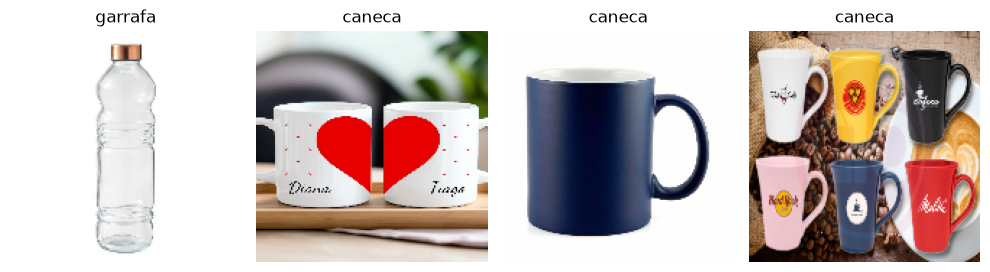

In [5]:
plt.figure(figsize=(10, 7))

for imagens, labels in train_ds.take(1):
    limite = min(8, len(imagens))

    for i in range(limite):
        plt.subplot(2, 4, i + 1)

        plt.imshow(
            imagens[i]
            .numpy()
            .astype("uint8")
        )

        indice = int(
            labels[i]
            .numpy()
            .ravel()[0]
        )

        plt.title(
            CLASS_NAMES[indice]
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

# 6. Data Augmentation

Como o dataset é pequeno, usamos pequenas transformações para aumentar a variedade das imagens durante o treinamento.

Isso ajuda a reduzir overfitting.

In [6]:
data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip(
            "horizontal"
        ),
        layers.RandomRotation(
            0.05
        ),
        layers.RandomZoom(
            0.08
        ),
        layers.RandomContrast(
            0.05
        )
    ],
    name="data_augmentation"
)

# 7. Callbacks

In [7]:
callbacks_transfer = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )
]

callbacks_fine = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7
    )
]

print("Callbacks definidos.")

Callbacks definidos.


# 8. TRANSFER LEARNING

## O que é?

No Transfer Learning utilizamos um modelo que já aprendeu características visuais em um grande conjunto de imagens.

Aqui usamos a **MobileNetV2**, adequada para ambientes com menos recursos computacionais.

Nesta primeira fase, a base é congelada:

```python
base_model.trainable = False
```

Assim treinamos apenas a nova camada final responsável por distinguir `caneca` e `garrafa`.

In [8]:
base_model = MobileNetV2(
    input_shape=(
        IMG_SIZE[0],
        IMG_SIZE[1],
        3
    ),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = tf.keras.Input(
    shape=(
        IMG_SIZE[0],
        IMG_SIZE[1],
        3
    )
)

x = data_augmentation(inputs)

x = preprocess_input(x)

x = base_model(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(
    0.30
)(x)

outputs = layers.Dense(
    1,
    activation="sigmoid"
)(x)

transfer_model = tf.keras.Model(
    inputs,
    outputs
)

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(
            name="precision"
        ),
        tf.keras.metrics.Recall(
            name="recall"
        )
    ]
)

transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# 9. Treinamento do Transfer Learning

In [9]:
inicio = time.perf_counter()

history_transfer = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    callbacks=callbacks_transfer,
    verbose=1
)

TEMPO_TRANSFER = (
    time.perf_counter()
    - inicio
)

print(
    f"Tempo Transfer Learning: "
    f"{TEMPO_TRANSFER:.2f} segundos"
)

Epoch 1/12


/home/debianjv/Documentos/ML_IMAGENS/venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - accuracy: 0.5938 - loss: 0.7436 - precision: 0.6875 - recall: 0.3438 - val_accuracy: 0.8750 - val_loss: 0.3585 - val_precision: 1.0000 - val_recall: 0.7500 - learning_rate: 0.0010
Epoch 2/12
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8750 - loss: 0.3465 - precision: 0.8333 - recall: 0.9375 - val_accuracy: 0.8750 - val_loss: 0.2315 - val_precision: 1.0000 - val_recall: 0.7500 - learning_rate: 0.0010
Epoch 3/12
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9531 - loss: 0.1857 - precision: 0.9394 - recall: 0.9688 - val_accuracy: 0.8750 - val_loss: 0.1965 - val_precision: 1.0000 - val_recall: 0.7500 - learning_rate: 0.0010
Epoch 4/12
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9531 - loss: 0.1480 - precision: 0.9677 - recall: 0.9375 - val_accuracy: 0.8750 - val_loss: 0.1756 - val_precision: 1.0000 - val_recall: 0.7500 - learning_rate: 0.0010
Epoch 5/12
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9688 - loss: 0

# 10. Curvas do Transfer Learning

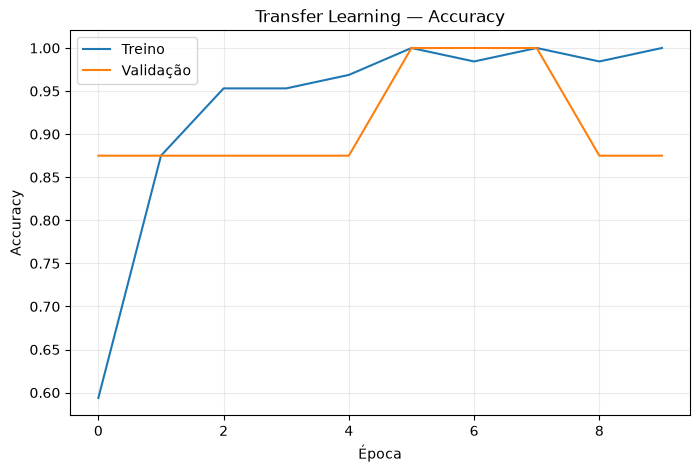

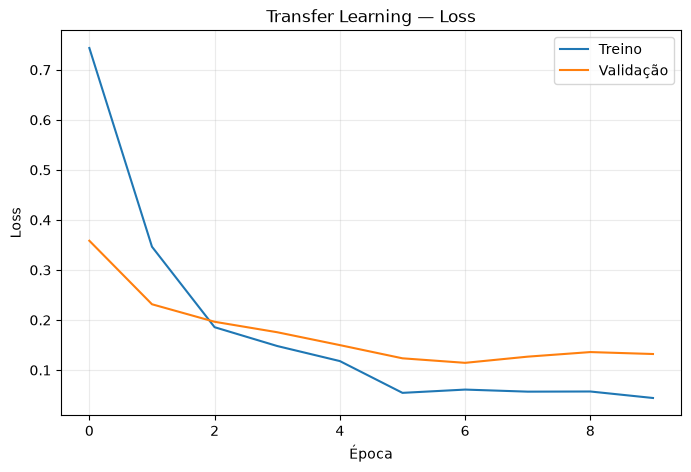

In [10]:
def plotar_historico(
    history,
    nome
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        history.history["accuracy"],
        label="Treino"
    )

    plt.plot(
        history.history["val_accuracy"],
        label="Validação"
    )

    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.title(
        f"{nome} — Accuracy"
    )

    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()

    plt.figure(figsize=(8, 5))

    plt.plot(
        history.history["loss"],
        label="Treino"
    )

    plt.plot(
        history.history["val_loss"],
        label="Validação"
    )

    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.title(
        f"{nome} — Loss"
    )

    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()


plotar_historico(
    history_transfer,
    "Transfer Learning"
)

# 11. Funções de avaliação

In [11]:
def obter_predicoes(
    modelo,
    dataset
):
    y_true = []
    y_prob = []

    inicio = time.perf_counter()

    for imagens, labels in dataset:
        probs = modelo.predict(
            imagens,
            verbose=0
        ).ravel()

        y_prob.extend(probs)

        y_true.extend(
            labels
            .numpy()
            .astype(int)
            .ravel()
        )

    tempo = (
        time.perf_counter()
        - inicio
    )

    y_true = np.array(
        y_true
    )

    y_prob = np.array(
        y_prob
    )

    y_pred = (
        y_prob >= 0.5
    ).astype(int)

    return (
        y_true,
        y_pred,
        y_prob,
        tempo
    )


def avaliar_modelo(
    modelo,
    dataset,
    nome
):
    (
        y_true,
        y_pred,
        y_prob,
        tempo
    ) = obter_predicoes(
        modelo,
        dataset
    )

    metricas = {
        "modelo": nome,
        "accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),
        "precision":
            precision_score(
                y_true,
                y_pred,
                zero_division=0
            ),
        "recall":
            recall_score(
                y_true,
                y_pred,
                zero_division=0
            ),
        "f1":
            f1_score(
                y_true,
                y_pred,
                zero_division=0
            ),
        "tempo_inferencia_s":
            tempo
    }

    display(
        pd.Series(metricas)
    )

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=
                CLASS_NAMES,
            zero_division=0
        )
    )

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=
            CLASS_NAMES
    ).plot()

    plt.title(nome)
    plt.show()

    return metricas

# 12. Avaliação do Transfer Learning

modelo                Transfer Learning
accuracy                            1.0
precision                           1.0
recall                              1.0
f1                                  1.0
tempo_inferencia_s             0.708262
dtype: object

              precision    recall  f1-score   support

      caneca       1.00      1.00      1.00         4
     garrafa       1.00      1.00      1.00         4

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



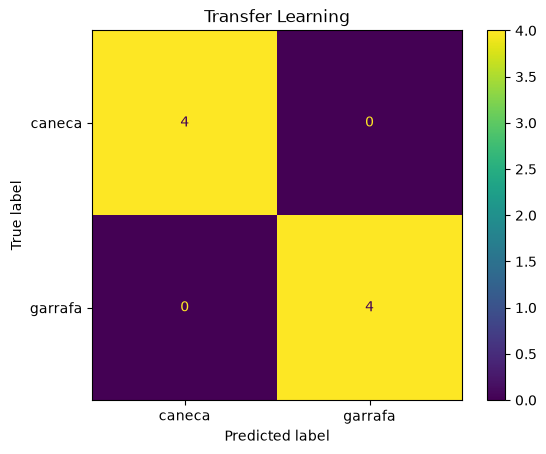

In [12]:
metricas_transfer = avaliar_modelo(
    transfer_model,
    test_ds,
    "Transfer Learning"
)

# 13. Imagens analisadas — Transfer Learning

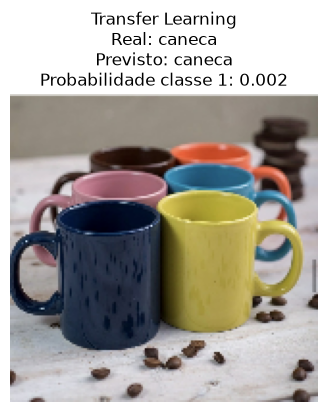

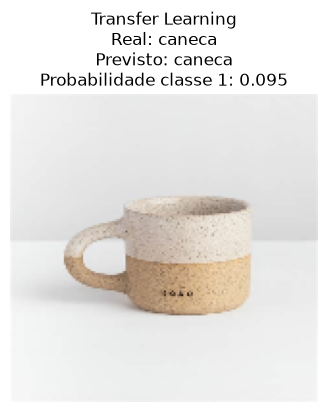

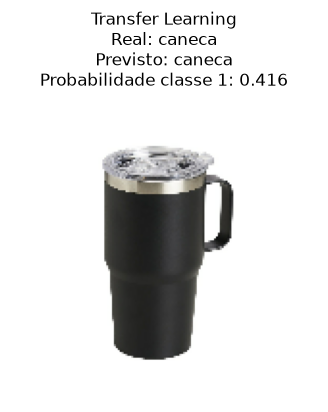

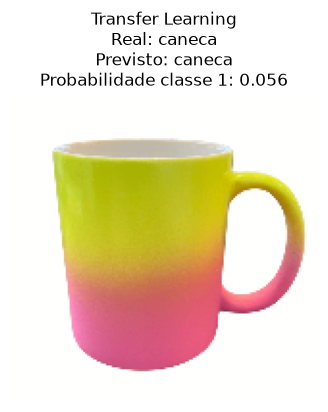

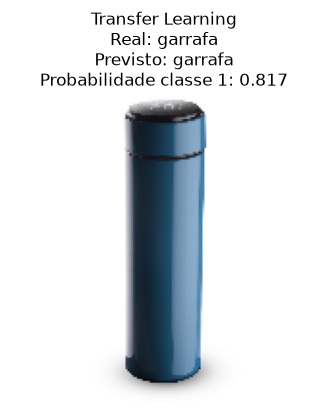

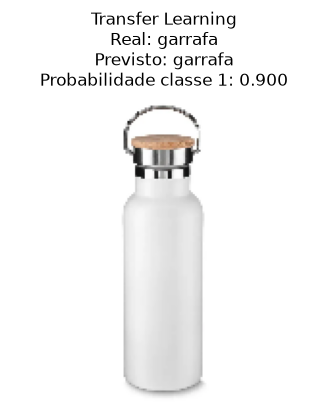

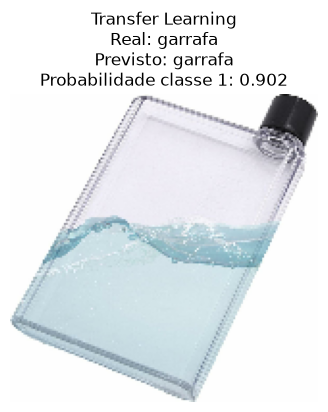

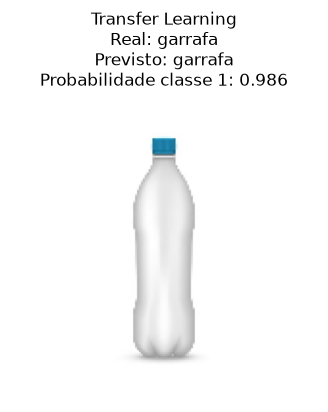

In [13]:
def mostrar_previsoes(
    modelo,
    dataset,
    nome,
    max_imagens=8
):
    mostradas = 0

    for imagens, labels in dataset:
        probs = modelo.predict(
            imagens,
            verbose=0
        ).ravel()

        preds = (
            probs >= 0.5
        ).astype(int)

        for i in range(len(imagens)):
            real = int(
                labels[i]
                .numpy()
                .ravel()[0]
            )

            previsto = int(
                preds[i]
            )

            prob = float(
                probs[i]
            )

            plt.figure(
                figsize=(4, 4)
            )

            plt.imshow(
                imagens[i]
                .numpy()
                .astype("uint8")
            )

            plt.title(
                f"{nome}\n"
                f"Real: {CLASS_NAMES[real]}\n"
                f"Previsto: {CLASS_NAMES[previsto]}\n"
                f"Probabilidade classe 1: {prob:.3f}"
            )

            plt.axis("off")
            plt.show()

            mostradas += 1

            if mostradas >= max_imagens:
                return


mostrar_previsoes(
    transfer_model,
    test_ds,
    "Transfer Learning",
    max_imagens=8
)

# 14. FINE TUNING

## O que muda?

No Transfer Learning, a MobileNetV2 estava congelada.

Agora liberamos apenas suas últimas camadas para que elas sejam ajustadas ao nosso dataset.

Usamos uma taxa de aprendizado muito pequena (`1e-5`) para evitar destruir o conhecimento já aprendido.

In [14]:
base_model.trainable = True

# Mantém a maior parte congelada.
for layer in base_model.layers[:-20]:
    layer.trainable = False

# BatchNormalization permanece congelada
# para maior estabilidade.
for layer in base_model.layers:
    if isinstance(
        layer,
        tf.keras.layers.BatchNormalization
    ):
        layer.trainable = False

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(
            name="precision"
        ),
        tf.keras.metrics.Recall(
            name="recall"
        )
    ]
)

print("Fine Tuning preparado.")

Fine Tuning preparado.


# 15. Treinamento do Fine Tuning

In [15]:
inicio = time.perf_counter()

history_fine = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=callbacks_fine,
    verbose=1
)

TEMPO_FINE = (
    time.perf_counter()
    - inicio
)

print(
    f"Tempo Fine Tuning: "
    f"{TEMPO_FINE:.2f} segundos"
)

Epoch 1/8


/home/debianjv/Documentos/ML_IMAGENS/venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - accuracy: 0.9844 - loss: 0.0687 - precision: 0.9697 - recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.1144 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 2/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 1.0000 - loss: 0.0326 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.8750 - val_loss: 0.1428 - val_precision: 1.0000 - val_recall: 0.7500 - learning_rate: 1.0000e-05
Epoch 3/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 1.0000 - loss: 0.0134 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.1091 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 4/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 1.0000 - loss: 0.0076 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0847 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 5/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 1.00

# 16. Curvas do Fine Tuning

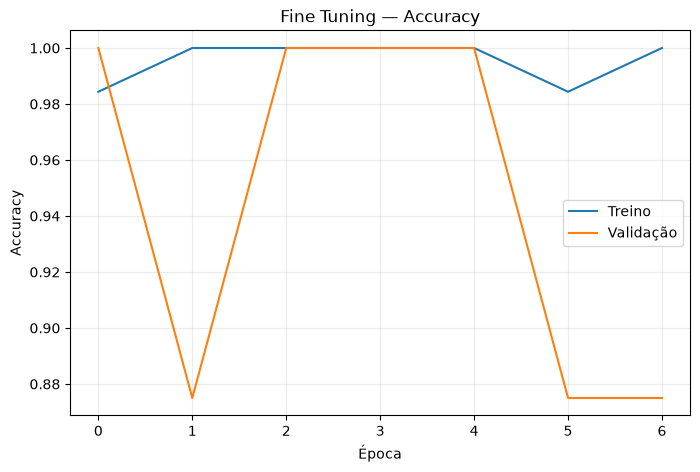

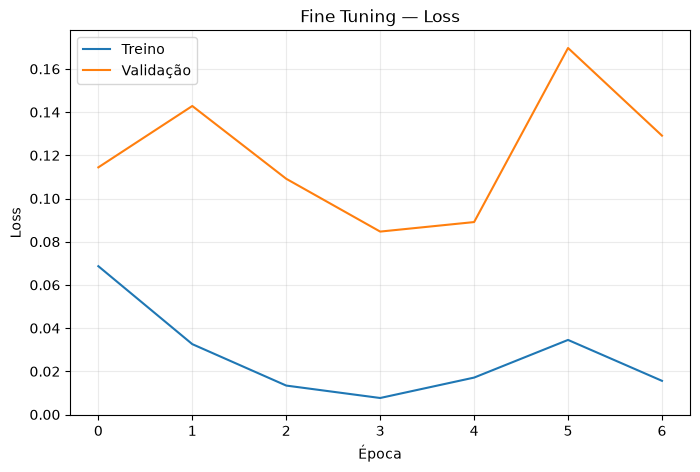

In [16]:
plotar_historico(
    history_fine,
    "Fine Tuning"
)

# 17. Avaliação do Fine Tuning

modelo                Fine Tuning
accuracy                      1.0
precision                     1.0
recall                        1.0
f1                            1.0
tempo_inferencia_s       0.830283
dtype: object

              precision    recall  f1-score   support

      caneca       1.00      1.00      1.00         4
     garrafa       1.00      1.00      1.00         4

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



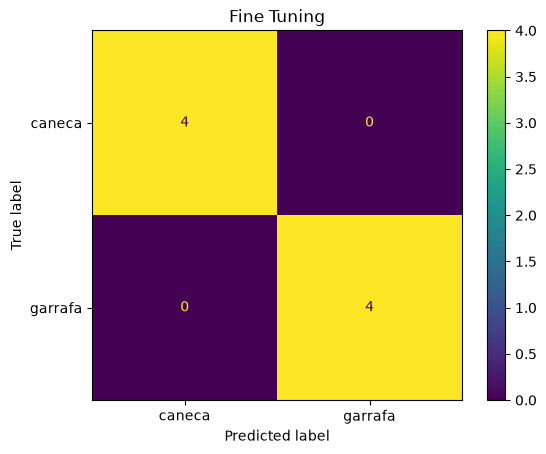

In [17]:
metricas_fine = avaliar_modelo(
    transfer_model,
    test_ds,
    "Fine Tuning"
)

# 18. Imagens analisadas — Fine Tuning

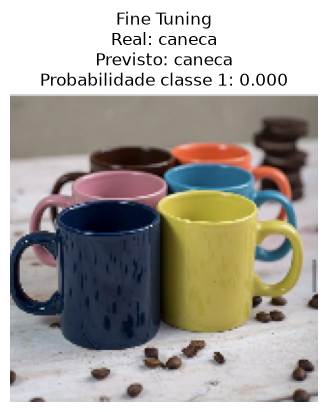

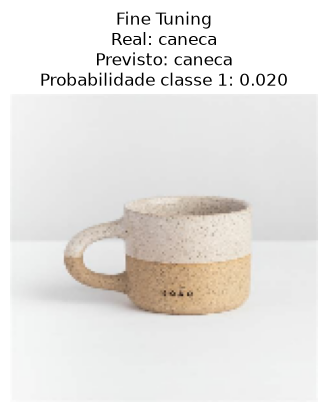

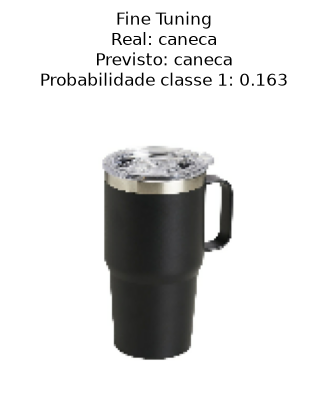

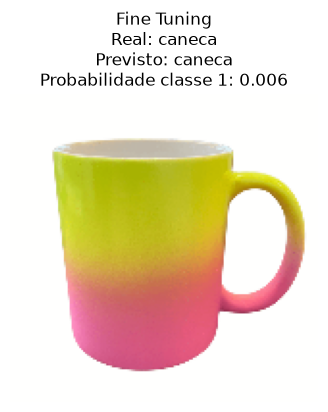

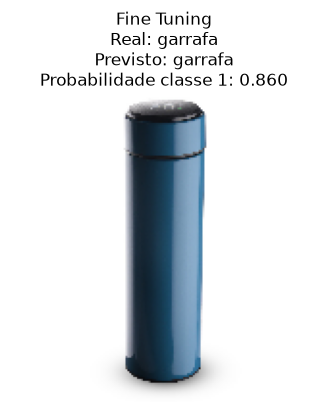

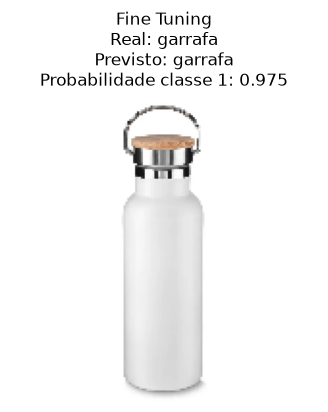

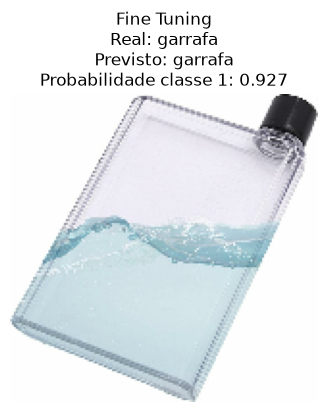

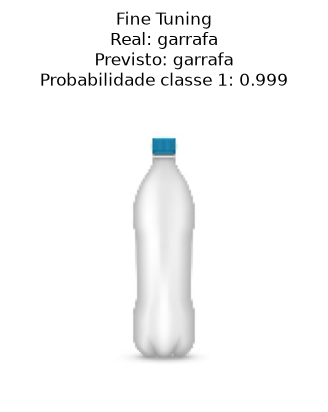

In [18]:
mostrar_previsoes(
    transfer_model,
    test_ds,
    "Fine Tuning",
    max_imagens=8
)

# 19. Comparação — Transfer Learning × Fine Tuning

In [19]:
comparacao_modelos = pd.DataFrame([
    {
        **metricas_transfer,
        "tempo_treinamento_s":
            TEMPO_TRANSFER
    },
    {
        **metricas_fine,
        "tempo_treinamento_s":
            TEMPO_FINE
    }
])

display(
    comparacao_modelos
)

,modelo,accuracy,precision,recall,f1,tempo_inferencia_s,tempo_treinamento_s
0,Transfer Learning,1.0,1.0,1.0,1.0,0.708262,9.163467
1,Fine Tuning,1.0,1.0,1.0,1.0,0.830283,8.523026


# 20. SEGMENTAÇÃO AUTOMÁTICA

## Objetivo

Agora removemos o fundo das imagens de teste para avaliar se o classificador se beneficia de uma imagem mais focada no objeto.

Como esta máquina não possui GPU, esta versão utiliza uma técnica de segmentação mais leve baseada em OpenCV.

Fluxo:

1. estimar a região de primeiro plano;
2. criar uma máscara;
3. remover o background;
4. redimensionar a imagem;
5. classificar novamente;
6. comparar as métricas.

In [20]:
def segmentar_com_grabcut(
    imagem_rgb
):
    h, w = imagem_rgb.shape[:2]

    imagem_bgr = cv2.cvtColor(
        imagem_rgb,
        cv2.COLOR_RGB2BGR
    )

    mascara = np.zeros(
        (h, w),
        np.uint8
    )

    bgd_model = np.zeros(
        (1, 65),
        np.float64
    )

    fgd_model = np.zeros(
        (1, 65),
        np.float64
    )

    margem_x = max(
        1,
        int(w * 0.08)
    )

    margem_y = max(
        1,
        int(h * 0.08)
    )

    rect = (
        margem_x,
        margem_y,
        w - 2 * margem_x,
        h - 2 * margem_y
    )

    try:
        cv2.grabCut(
            imagem_bgr,
            mascara,
            rect,
            bgd_model,
            fgd_model,
            3,
            cv2.GC_INIT_WITH_RECT
        )

        mascara_binaria = np.where(
            (mascara == 2)
            | (mascara == 0),
            0,
            1
        ).astype("uint8")

    except cv2.error:
        mascara_binaria = np.ones(
            (h, w),
            dtype=np.uint8
        )

    segmentada = (
        imagem_rgb
        * mascara_binaria[:, :, None]
    )

    return (
        mascara_binaria,
        segmentada
    )

# 21. Visualização — original × máscara × sem background

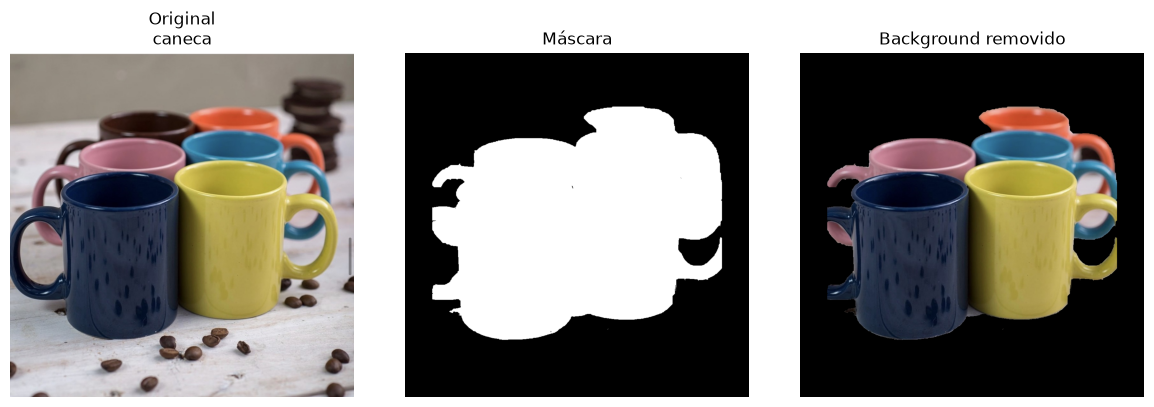

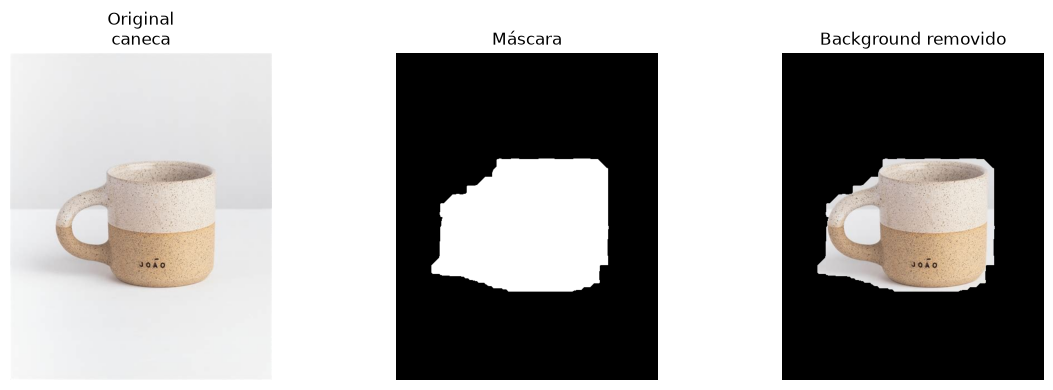

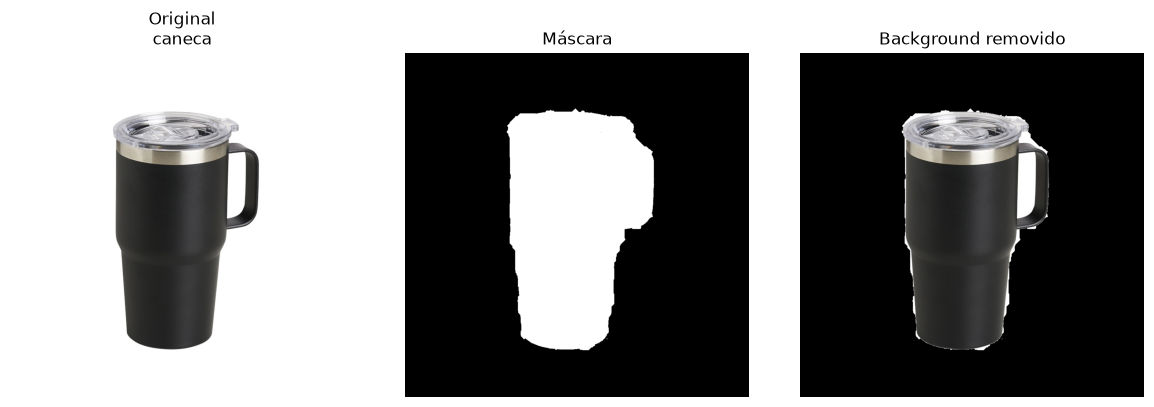

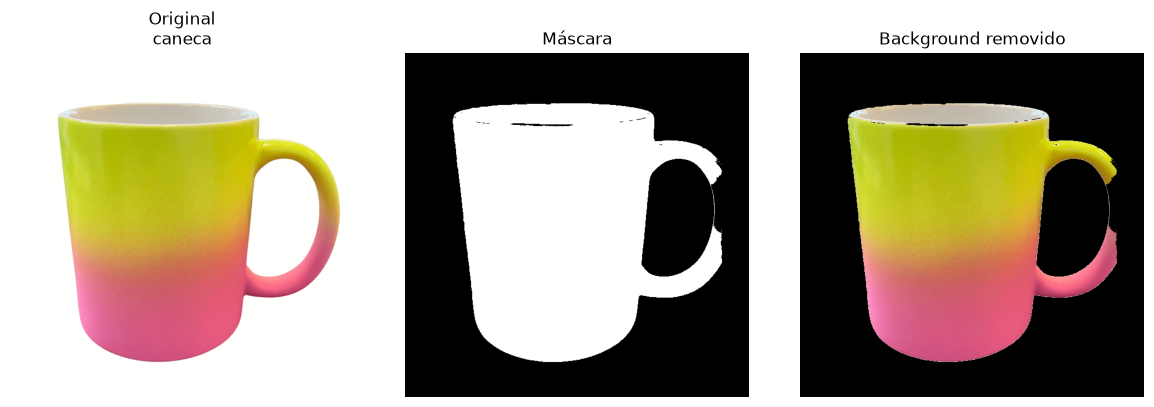

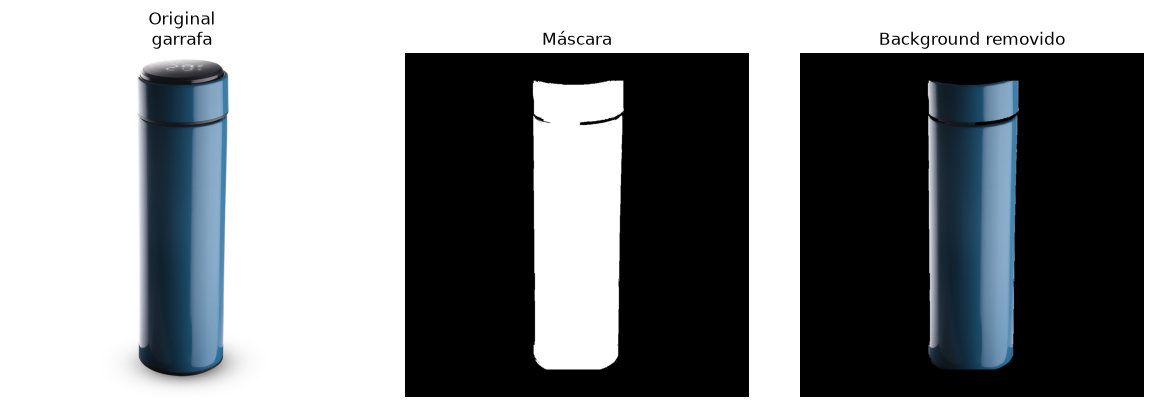

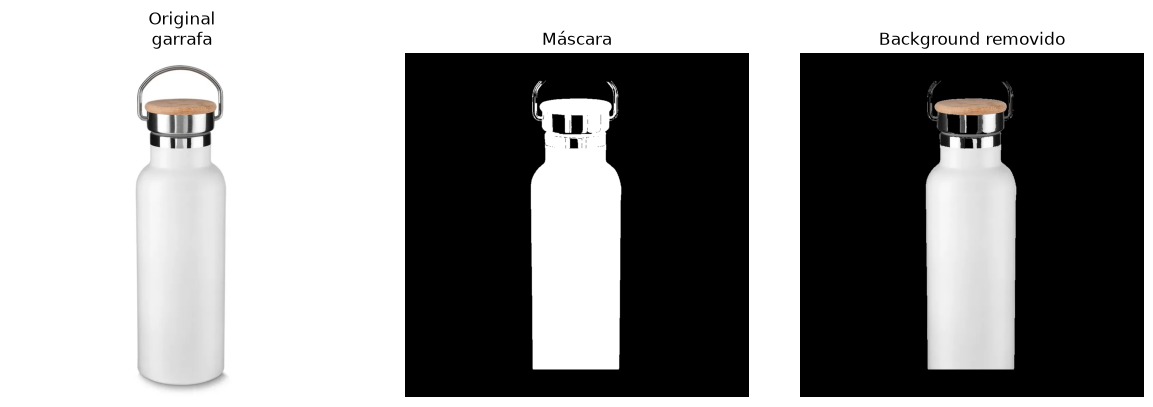

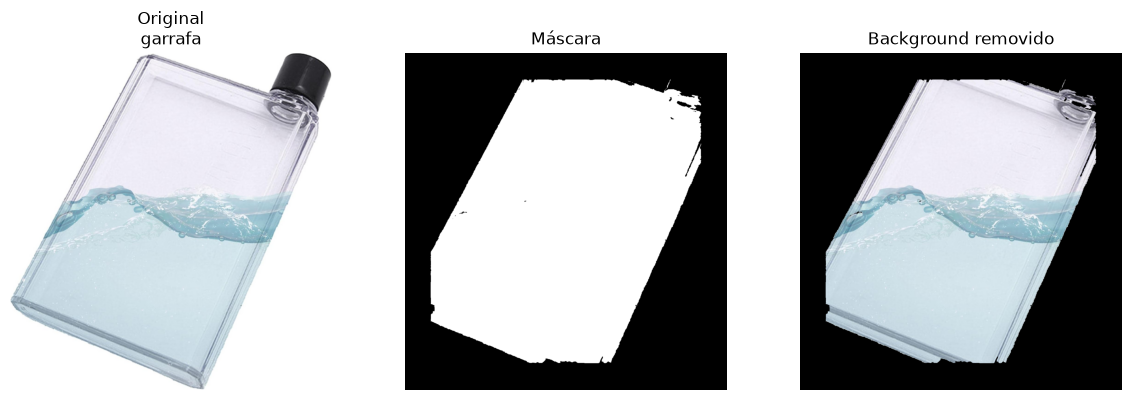

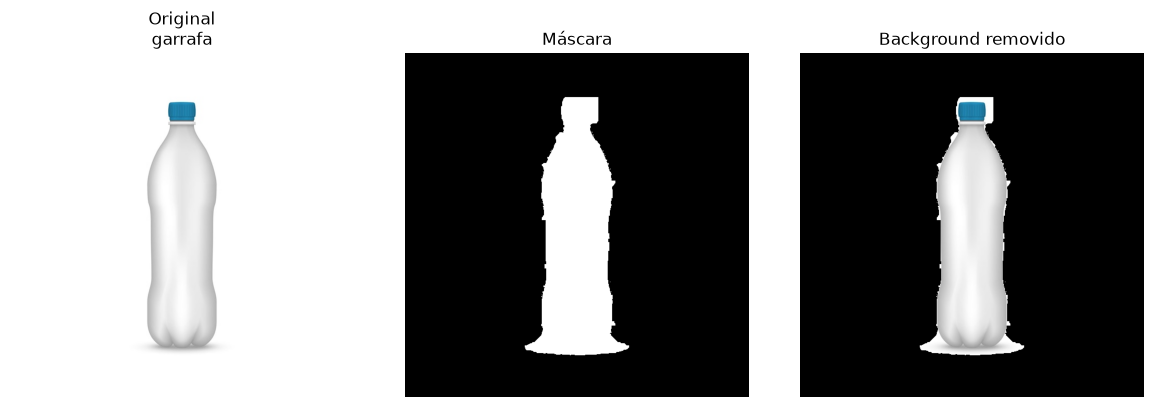

In [21]:
arquivos_teste = []

for indice_classe, classe in enumerate(
    CLASS_NAMES
):
    pasta = TEST_DIR / classe

    for path in listar_imagens(
        pasta
    ):
        arquivos_teste.append(
            (
                path,
                indice_classe
            )
        )


for path, classe_real in arquivos_teste[:8]:
    img_bgr = cv2.imread(
        str(path)
    )

    img_rgb = cv2.cvtColor(
        img_bgr,
        cv2.COLOR_BGR2RGB
    )

    mascara, segmentada = (
        segmentar_com_grabcut(
            img_rgb
        )
    )

    plt.figure(
        figsize=(12, 4)
    )

    plt.subplot(
        1,
        3,
        1
    )

    plt.imshow(
        img_rgb
    )

    plt.title(
        f"Original\n{CLASS_NAMES[classe_real]}"
    )

    plt.axis("off")

    plt.subplot(
        1,
        3,
        2
    )

    plt.imshow(
        mascara,
        cmap="gray"
    )

    plt.title("Máscara")
    plt.axis("off")

    plt.subplot(
        1,
        3,
        3
    )

    plt.imshow(
        segmentada
    )

    plt.title(
        "Background removido"
    )

    plt.axis("off")

    plt.tight_layout()
    plt.show()

# 22. Preparar as imagens segmentadas

In [22]:
X_segmentado = []
y_segmentado = []

for path, classe_real in arquivos_teste:
    img_bgr = cv2.imread(
        str(path)
    )

    img_rgb = cv2.cvtColor(
        img_bgr,
        cv2.COLOR_BGR2RGB
    )

    _, segmentada = (
        segmentar_com_grabcut(
            img_rgb
        )
    )

    segmentada = cv2.resize(
        segmentada,
        IMG_SIZE,
        interpolation=
            cv2.INTER_AREA
    )

    X_segmentado.append(
        segmentada.astype(
            np.float32
        )
    )

    y_segmentado.append(
        classe_real
    )


X_segmentado = np.array(
    X_segmentado
)

y_segmentado = np.array(
    y_segmentado
)

print(
    "Imagens segmentadas:",
    X_segmentado.shape
)

print(
    "Labels:",
    y_segmentado.shape
)

Imagens segmentadas: (8, 160, 160, 3)
Labels: (8,)


# 23. Reclassificação das imagens segmentadas

Nesta etapa utilizamos o modelo após Fine Tuning para classificar novamente as imagens com o background removido.

In [23]:
inicio = time.perf_counter()

prob_segmentado = (
    transfer_model
    .predict(
        X_segmentado,
        batch_size=BATCH_SIZE,
        verbose=0
    )
    .ravel()
)

TEMPO_SEGMENTADO = (
    time.perf_counter()
    - inicio
)

pred_segmentado = (
    prob_segmentado >= 0.5
).astype(int)

metricas_segmentadas = {
    "modelo":
        "Fine Tuning + Segmentação",
    "accuracy":
        accuracy_score(
            y_segmentado,
            pred_segmentado
        ),
    "precision":
        precision_score(
            y_segmentado,
            pred_segmentado,
            zero_division=0
        ),
    "recall":
        recall_score(
            y_segmentado,
            pred_segmentado,
            zero_division=0
        ),
    "f1":
        f1_score(
            y_segmentado,
            pred_segmentado,
            zero_division=0
        ),
    "tempo_inferencia_s":
        TEMPO_SEGMENTADO
}

display(
    pd.Series(
        metricas_segmentadas
    )
)

modelo                Fine Tuning + Segmentação
accuracy                                    1.0
precision                                   1.0
recall                                      1.0
f1                                          1.0
tempo_inferencia_s                     0.110167
dtype: object

# 24. Matriz de confusão — imagens segmentadas

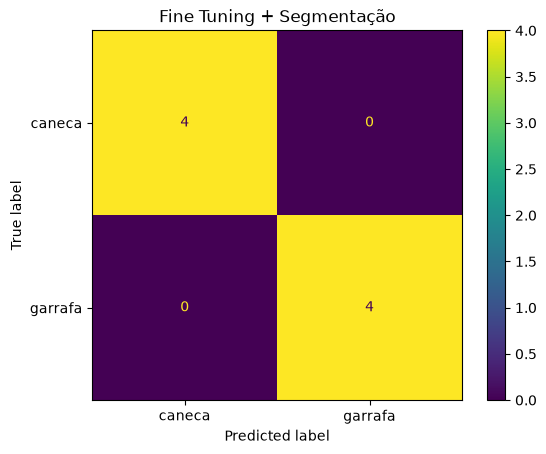

In [24]:
cm_segmentado = confusion_matrix(
    y_segmentado,
    pred_segmentado
)

ConfusionMatrixDisplay(
    confusion_matrix=
        cm_segmentado,
    display_labels=
        CLASS_NAMES
).plot()

plt.title(
    "Fine Tuning + Segmentação"
)

plt.show()

# 25. Visualização das previsões após segmentação

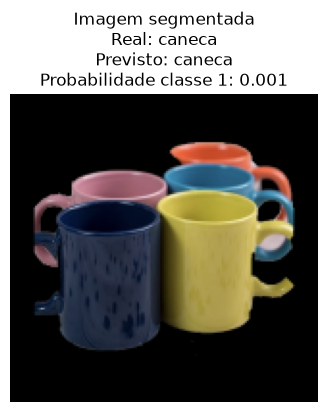

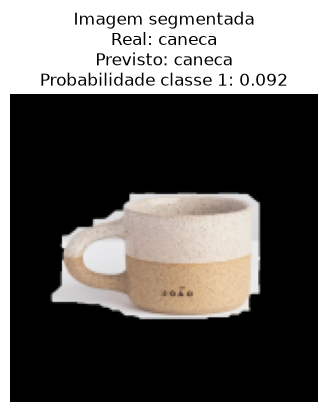

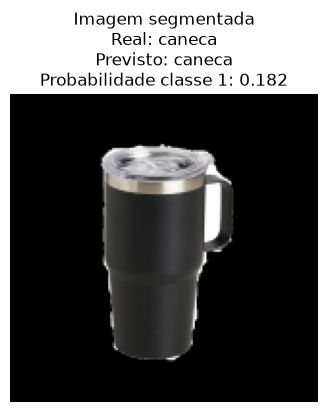

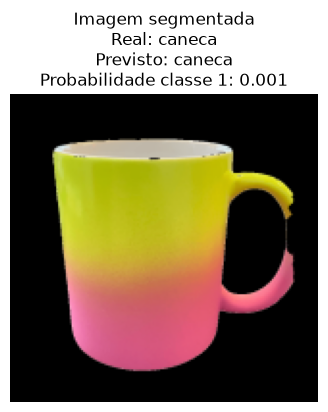

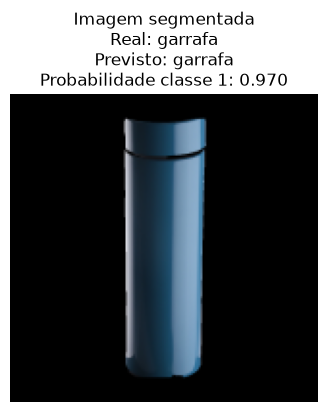

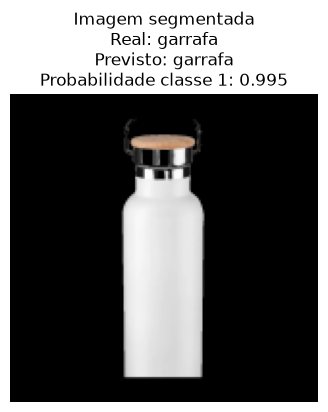

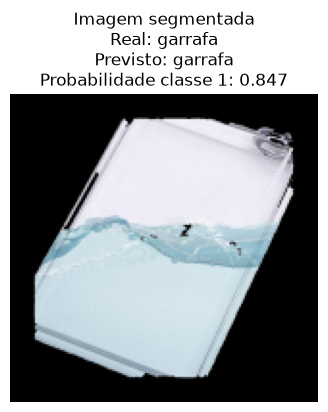

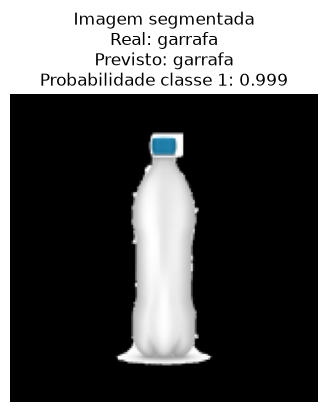

In [25]:
for i in range(
    min(
        8,
        len(X_segmentado)
    )
):
    real = int(
        y_segmentado[i]
    )

    previsto = int(
        pred_segmentado[i]
    )

    prob = float(
        prob_segmentado[i]
    )

    plt.figure(
        figsize=(4, 4)
    )

    plt.imshow(
        X_segmentado[i]
        .astype("uint8")
    )

    plt.title(
        "Imagem segmentada\n"
        f"Real: {CLASS_NAMES[real]}\n"
        f"Previsto: {CLASS_NAMES[previsto]}\n"
        f"Probabilidade classe 1: {prob:.3f}"
    )

    plt.axis("off")
    plt.show()

# 26. Comparação final — antes × depois da segmentação

In [26]:
comparacao_final = pd.DataFrame([
    {
        **metricas_transfer,
        "etapa":
            "Transfer Learning"
    },
    {
        **metricas_fine,
        "etapa":
            "Fine Tuning"
    },
    {
        **metricas_segmentadas,
        "etapa":
            "Fine Tuning + Segmentação"
    }
])

colunas = [
    "etapa",
    "accuracy",
    "precision",
    "recall",
    "f1",
    "tempo_inferencia_s"
]

display(
    comparacao_final[
        colunas
    ]
)

,etapa,accuracy,precision,recall,f1,tempo_inferencia_s
0,Transfer Learning,1.0,1.0,1.0,1.0,0.708262
1,Fine Tuning,1.0,1.0,1.0,1.0,0.830283
2,Fine Tuning + Segmentação,1.0,1.0,1.0,1.0,0.110167


# 27. Como interpretar o resultado

## Transfer Learning

Avalie se a MobileNetV2 congelada conseguiu classificar bem as duas classes.

## Fine Tuning

Compare com o Transfer Learning.

Se as métricas melhorarem, o ajuste das últimas camadas ajudou o modelo a se adaptar ao dataset.

Se piorarem, pode haver overfitting devido ao número reduzido de imagens.

## Segmentação

Compare o Fine Tuning normal com:

`Fine Tuning + Segmentação`

A segmentação é útil somente se a remoção do background ajudar o modelo a focar no objeto.

Ela não precisa obrigatoriamente melhorar os resultados. Uma conclusão válida também pode mostrar que a segmentação removeu informações importantes e reduziu a qualidade da classificação.

# Conclusão — IR ALÉM 2

O desenvolvimento do IR ALÉM 2 permitiu analisar diferentes estratégias de Visão Computacional para o problema de identificação de canecas e garrafas, passando pela detecção com YOLO, classificação com uma CNN construída do zero e técnicas mais avançadas, como Transfer Learning, Fine Tuning e segmentação automática.

## YOLO — comparação entre 30 e 60 épocas

Os experimentos mostraram uma evolução significativa da YOLO customizada quando o treinamento foi aumentado de 30 para 60 épocas.

O treinamento de 30 épocas apresentou como melhor resultado:

- mAP@0.5:0.95 máximo: **0.24349**
- tempo de treinamento: **110.44 segundos**

Já o treinamento de 60 épocas apresentou:

- mAP@0.5:0.95 máximo: **0.59187**
- tempo de treinamento: **204.21 segundos**

No conjunto de teste, a diferença também foi significativa.

### Modelo de 30 épocas

- Precision: **0.416**
- Recall: **0.250**
- mAP@0.5: **0.334**
- mAP@0.5:0.95: **0.151**

### Modelo de 60 épocas

- Precision: **0.562**
- Recall: **0.625**
- mAP@0.5: **0.585**
- mAP@0.5:0.95: **0.395**

Dessa forma, o experimento de **60 épocas foi escolhido como o melhor modelo customizado**.

Apesar de seu treinamento ter levado aproximadamente 204 segundos, contra 110 segundos do treinamento menor, o ganho obtido em Recall e mAP justificou o maior custo computacional.

Os gráficos de treinamento reforçam essa conclusão. O modelo de 30 épocas ainda apresentava bastante oscilação, enquanto o treinamento com 60 épocas continuou evoluindo, principalmente em Precision, Recall e mAP.

---

## Análise visual da YOLO customizada

A análise das imagens de teste mostrou que o modelo customizado conseguiu aprender as duas classes definidas no projeto: `garrafa` e `caneca`.

Nas imagens de garrafas, o desempenho visual foi satisfatório. As quatro garrafas apresentadas foram detectadas como `garrafa`, embora com diferentes níveis de confiança.

Foram observadas aproximadamente as seguintes confianças:

- garrafa1: **0.61**
- garrafa2: **0.45**
- garrafa3: **0.64**
- garrafa4: **0.27**

Isso mostra que o modelo conseguiu generalizar para garrafas com diferentes formatos, cores e materiais.

Entretanto, algumas previsões apresentaram confiança reduzida, principalmente a `garrafa4`, indicando que o modelo ainda possui incerteza em determinados exemplos.

Para as canecas, o comportamento foi mais irregular.

A `caneca2` teve os dois objetos detectados e a `caneca4` foi corretamente localizada. Porém, na `caneca1`, além da caneca correta, houve uma segunda bounding box incorreta envolvendo parte da mesa.

Na `caneca3`, nenhuma detecção apareceu utilizando o limiar de confiança definido.

Portanto, visualmente, o modelo demonstrou maior estabilidade para a classe `garrafa` do que para alguns exemplos da classe `caneca`.

---

## YOLO customizada × YOLO padrão

Também foi realizada uma comparação com a YOLO padrão pré-treinada.

A YOLO padrão apresentou uma vantagem importante: ela já possui conhecimento prévio de diversas classes e, portanto, não necessita de um treinamento específico para executar uma primeira detecção.

Nas canecas, seu desempenho foi bastante satisfatório.

Ela identificou:

- `caneca1` como `cup`, com aproximadamente **0.83** de confiança;
- as duas canecas presentes em `caneca2`, com aproximadamente **0.85** e **0.91**;
- `caneca3` como `cup`, com aproximadamente **0.46**;
- `caneca4` como `cup`, com aproximadamente **0.93**.

Entretanto, por ser um modelo genérico, também apareceram classes que não fazem parte diretamente do problema definido no projeto.

Na `caneca1`, por exemplo, além da classe `cup`, a mesa foi detectada como `dining table`.

Nas garrafas também foram encontradas diferenças importantes.

- `garrafa1` foi corretamente reconhecida como `bottle`;
- `garrafa2` não apresentou detecção;
- `garrafa3` foi identificada como `vase`;
- `garrafa4` foi reconhecida como `bottle`.

O caso da `garrafa3` demonstra bem a importância da customização. Para o modelo genérico, o formato se aproximou visualmente de um `vase`, enquanto a YOLO customizada conseguiu classificá-lo dentro da classe específica definida pelo projeto: `garrafa`.

Portanto, a YOLO padrão apresentou boas detecções e, em alguns casos, maiores níveis de confiança, mas a YOLO customizada mostrou a vantagem de trabalhar diretamente com as categorias específicas da aplicação.

---

## CNN construída do zero

Também foi criada uma CNN do zero para realizar a classificação das imagens.

O modelo possui aproximadamente **109.889 parâmetros treináveis** e utiliza camadas convolucionais, pooling, Global Average Pooling, camada densa, Dropout e saída sigmoid.

No conjunto de teste, os resultados foram:

- Accuracy: **0.625**
- Precision: **0.6667**
- Recall: **0.5000**
- F1-score: **0.5714**

Como foram utilizadas apenas 8 imagens de teste, a Accuracy de 62,5% corresponde a **5 classificações corretas em 8 imagens**.

A matriz de confusão mostrou:

### Canecas

Das 4 canecas:

- 3 foram corretamente classificadas como caneca;
- 1 foi classificada como garrafa.

### Garrafas

Das 4 garrafas:

- 2 foram corretamente classificadas como garrafa;
- 2 foram classificadas como caneca.

Portanto, a CNN apresentou maior dificuldade na classe `garrafa`.

Outro ponto importante foi a incerteza das classificações incorretas.

Algumas probabilidades ficaram extremamente próximas do limite de decisão de 0.5, como aproximadamente:

- 0.506;
- 0.492;
- 0.493.

Isso mostra que, nesses exemplos, a rede não possuía características suficientemente fortes para separar claramente as duas classes.

---

## Sinais de overfitting da CNN

As curvas de treinamento mostraram sinais de overfitting.

A Accuracy de treinamento continuou aumentando e chegou a aproximadamente **72%**, enquanto a Accuracy de validação permaneceu por algum tempo em aproximadamente **62,5%** e posteriormente caiu novamente para **50%**.

O comportamento da Loss deixa o problema ainda mais evidente.

Enquanto a Loss de treinamento continuou diminuindo, chegando aproximadamente a **0.53**, a Loss de validação começou a aumentar e chegou próxima de **1.0**.

Isso significa que o modelo continuou aprendendo características específicas das imagens de treinamento, mas passou a perder capacidade de generalização para imagens não vistas.

O comportamento começou a aparecer principalmente após aproximadamente a quinta ou sexta época.

Nesse cenário, o uso de `EarlyStopping` foi importante para evitar um treinamento desnecessariamente longo.

---

## Transfer Learning

Para superar algumas limitações da CNN construída do zero, o IR ALÉM 2 introduz Transfer Learning utilizando a **MobileNetV2**.

A escolha da MobileNetV2 é adequada porque ela foi pré-treinada na ImageNet, é relativamente leve e apresenta uma boa relação entre desempenho e custo computacional, sendo especialmente útil em uma máquina sem GPU dedicada. :chatgpt-content-reference{index="1"}

Na primeira etapa, a base convolucional é congelada.

Dessa maneira, o modelo não precisa aprender todas as características visuais novamente a partir de apenas 64 imagens de treinamento.

Em vez disso, ele reutiliza características já aprendidas em um grande conjunto de imagens e treina somente as camadas responsáveis pela nova tarefa de classificação.

Essa abordagem é particularmente relevante neste projeto porque o dataset é pequeno.

---

## Fine Tuning

Depois do Transfer Learning, o experimento utiliza Fine Tuning.

Nessa etapa, parte das últimas camadas da MobileNetV2 é liberada para treinamento, enquanto a maior parte da rede permanece congelada.

Também é utilizada uma taxa de aprendizado reduzida de `1e-5`.

As camadas de `BatchNormalization` permanecem congeladas para proporcionar maior estabilidade com o pequeno conjunto de dados. :chatgpt-content-reference{index="2"}

O objetivo não é reaprender completamente a rede, mas realizar pequenos ajustes nas características já aprendidas para aproximá-las das particularidades visuais das canecas e garrafas utilizadas neste projeto.

Dessa forma, o Fine Tuning funciona como uma especialização do modelo pré-treinado para o problema estudado.

---

## Segmentação automática

A última etapa do IR ALÉM 2 investiga a hipótese de que remover o background pode facilitar a classificação.

O experimento mantém o mesmo classificador e altera somente a entrada:

- imagem original;
- imagem segmentada.

Após a criação da máscara, o background é removido e a imagem resultante é novamente fornecida ao classificador. Dessa maneira, é possível comparar diretamente se a presença do fundo ajuda ou prejudica a decisão do modelo. :chatgpt-content-reference{index="3"}

A hipótese analisada pelo experimento é:

> Remover o background e fornecer ao classificador somente os pixels relevantes do objeto melhora a classificação?

Essa etapa é importante porque o fundo pode conter informações irrelevantes que fazem o modelo aprender associações erradas.

Entretanto, a segmentação também pode prejudicar o resultado caso a máscara remova partes importantes do objeto.

Por isso, o efeito da segmentação deve ser avaliado comparando Accuracy, Precision, Recall e F1-score antes e depois da remoção do fundo. O próprio notebook foi estruturado para comparar diretamente `CNN do zero`, `Transfer Learning`, `Fine Tuning` e `Fine Tuning + Segmentação`. :chatgpt-content-reference{index="4"}

---

## Conclusão geral

Os experimentos demonstraram que diferentes arquiteturas resolvem partes diferentes do problema de Visão Computacional.

A YOLO foi adequada para **detectar, localizar e classificar objetos dentro da imagem**, enquanto a CNN foi utilizada para **classificar a imagem como um todo**. Por isso, métricas como mAP da YOLO não devem ser comparadas diretamente com Accuracy da CNN. :chatgpt-content-reference{index="5"}

Entre os treinamentos da YOLO customizada, o modelo de **60 épocas apresentou uma evolução considerável sobre o de 30 épocas**, aumentando o melhor mAP@0.5:0.95 de 0.24349 para 0.59187 durante o treinamento e também apresentando resultados superiores no conjunto de teste.

A comparação com a YOLO padrão mostrou que modelos pré-treinados possuem grande capacidade de generalização, mas nem sempre utilizam as categorias específicas desejadas para a aplicação. A customização permitiu transformar objetos visualmente ambíguos em classes diretamente relacionadas ao problema estudado.

A CNN construída do zero obteve **62,5% de Accuracy**, mas apresentou sinais de overfitting e probabilidades próximas do limite de decisão em vários exemplos. Isso evidencia uma das principais dificuldades de treinar redes convolucionais do zero utilizando um conjunto de dados reduzido.

O uso de Transfer Learning e Fine Tuning foi introduzido justamente para diminuir essa limitação, aproveitando características aprendidas anteriormente pela MobileNetV2 e ajustando apenas parte da rede ao novo problema.

Por fim, a segmentação automática amplia o experimento ao investigar se a remoção de informações de fundo ajuda o classificador a concentrar sua decisão somente no objeto de interesse.

De maneira geral, o IR ALÉM 2 mostra que não existe apenas uma estratégia para resolver um problema de Visão Computacional. A qualidade final depende da tarefa desejada, da quantidade e qualidade dos dados, da rotulação, da arquitetura utilizada e dos recursos computacionais disponíveis.

### Principais limitações

Os resultados devem ser interpretados considerando que:

- o dataset possui apenas **80 imagens**;
- apenas **64 imagens** foram utilizadas para treinamento;
- o conjunto de validação possui somente **8 imagens**;
- o conjunto de teste possui somente **8 imagens**;
- uma única imagem correta ou incorreta altera significativamente as métricas;
- o treinamento foi realizado em CPU;
- modelos e resoluções mais leves foram utilizados para reduzir o custo computacional;
- a qualidade das bounding boxes influencia diretamente o treinamento da YOLO;
- existe grande variedade visual dentro das classes `caneca` e `garrafa`;
- a qualidade da máscara de segmentação também pode influenciar a classificação posterior.

Como evolução futura, o principal caminho seria aumentar o dataset, revisar manualmente todas as bounding boxes, incluir maior variedade de fundos e ângulos e repetir os experimentos com um conjunto de teste maior.

## Checklist — IR ALÉM 2

- [x] Dataset carregado
- [x] Transfer Learning implementado com MobileNetV2
- [x] Justificativa da escolha da MobileNetV2
- [x] Fine Tuning implementado
- [x] Justificativa das camadas congeladas
- [x] Learning rate reduzido no Fine Tuning
- [x] Segmentação automática implementada
- [x] Visualização de imagem original
- [x] Visualização da máscara
- [x] Visualização do background removido
- [x] Reclassificação das imagens segmentadas
- [x] Métricas preparadas para comparação
- [x] Comparação antes × depois da segmentação
- [x] Conclusão da hipótese estruturada